In [1]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [5]:
os.chdir(r"C:\Users\prade\OneDrive\Desktop\Data_CNN")

In [6]:
os.getcwd()

'C:\\Users\\prade\\OneDrive\\Desktop\\Data_CNN'

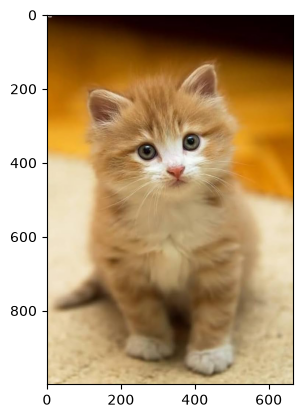

In [8]:
img = image.load_img(r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Training\Cat\Img1.jpg")
plt.imshow(img)

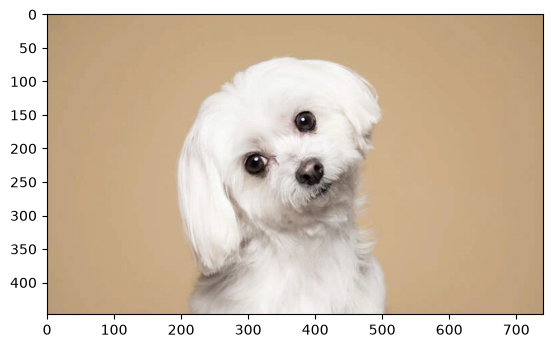

In [9]:
img = image.load_img(r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Training\Dog\dog1.webp")
plt.imshow(img)

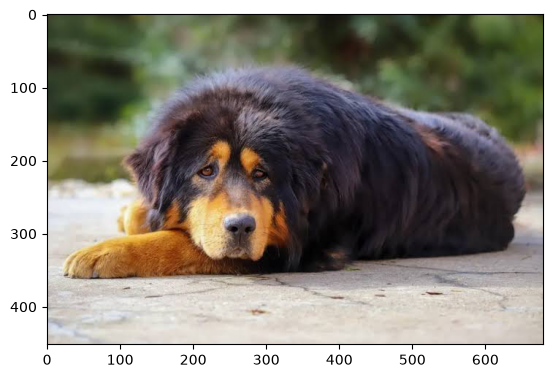

In [22]:
img = image.load_img(r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Testing\dogv1.jpeg")
plt.imshow(img)

In [23]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [24]:
tr_location = r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Training"
val_location = r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Validation"

In [25]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 3 images belonging to 2 classes.
Found 5 images belonging to 2 classes.


In [26]:
train_data.class_indices

{'Cat': 0, 'Dog': 1}

In [27]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [31]:
model.fit(train_data,steps_per_epoch=3, epochs= 10 , validation_data=valid_data)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 11s/step - accuracy: 0.0000e+00 - loss: 0.7093 - val_accuracy: 0.6000 - val_loss: 4.4740
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.6667 - loss: 3.2361 - val_accuracy: 0.4000 - val_loss: 1.6332
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step - accuracy: 0.3333 - loss: 1.5801 - val_accuracy: 0.6000 - val_loss: 0.6627
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.6667 - loss: 0.5772 - val_accuracy: 0.6000 - val_loss: 0.6835
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 1.0000 - loss: 0.3718 - val_accuracy: 0.6000 - val_loss: 0.8977
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 1.0000 - loss: 0.2377 - val_accuracy: 0.4000 - val_loss: 1.0641
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.3333 - loss: 0.5851 - val_accuracy: 0.6000 - val_loss: 1.4796
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6667 - loss: 0.4198 - val_accuracy: 0.2000 - val_lo

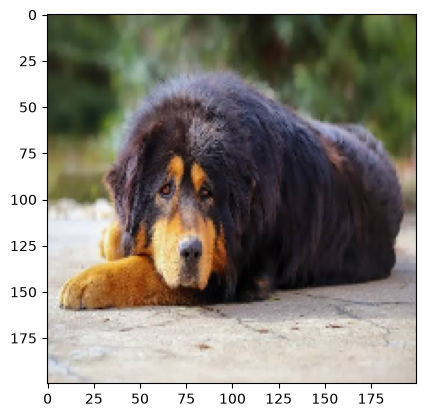

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Cat


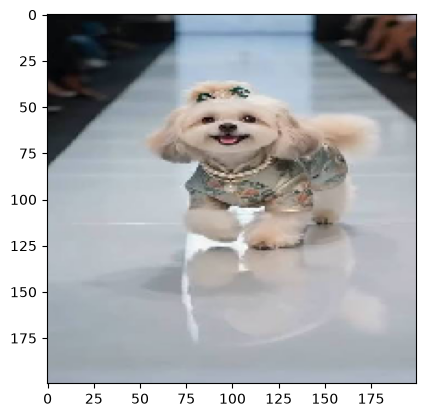

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Cat


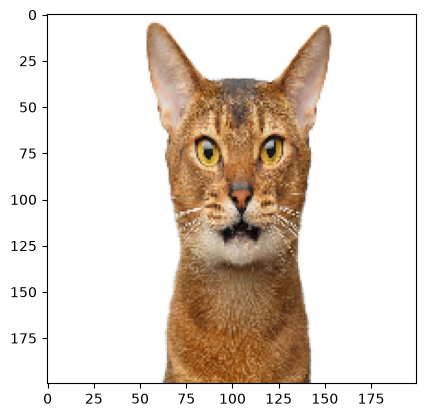

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Cat


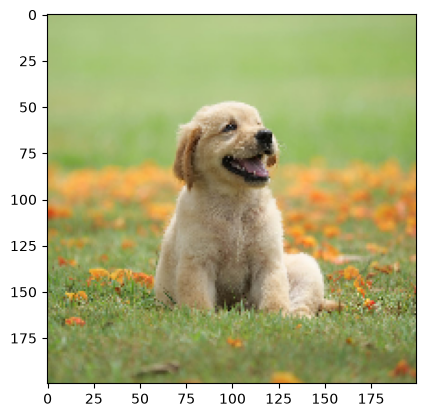

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Cat


In [32]:
path = r"C:\Users\prade\OneDrive\Desktop\Data_CNN\Testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("Cat")
    else:
        print("Dog")